In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

# التعرف على الداتا

In [4]:
df = pd.read_csv("sa_fund_prices_daily.csv")

In [6]:
df.head()

,Date,Company_Name,Ticker,Sector,Industry,Open,High,Low,Close,Adj_Close,Volume
0,2024-10-30,Alawwal MT30 ETF,9410.SR,Investment Fund,Saudi Equity ETF,10.00,10.02,9.97,9.97,9.97,192477
1,2024-10-31,Alawwal MT30 ETF,9410.SR,Investment Fund,Saudi Equity ETF,9.87,9.87,9.78,9.81,9.81,202390
2,2024-11-03,Alawwal MT30 ETF,9410.SR,Investment Fund,Saudi Equity ETF,9.78,10.40,9.77,10.00,10.00,1374971
3,2024-11-04,Alawwal MT30 ETF,9410.SR,Investment Fund,Saudi Equity ETF,10.02,10.64,9.98,10.02,10.02,3144740
4,2024-11-06,Alawwal MT30 ETF,9410.SR,Investment Fund,Saudi Equity ETF,9.98,10.00,9.79,9.87,9.87,866875


In [8]:
print(df["Company_Name"].unique())

['Alawwal MT30 ETF' 'Jadwa Saudi Equity ETF' 'Albilad MSCI Saudi ETF'
 'Franklin FTSE Saudi ETF' 'VanEck Gulf States ETF'
 'iShares MSCI Saudi KSA' 'TASI Index']


In [10]:
df.shape

(6708, 11)

In [12]:
# Keep only funds with full history (2019-2026)
funds = [
    "iShares MSCI Saudi KSA",
    "Franklin FTSE Saudi ETF",
    "TASI Index"
]

df = df[df["Company_Name"].isin(funds)].copy()
df.head()

,Date,Company_Name,Ticker,Sector,Industry,Open,High,Low,Close,Adj_Close,Volume
864,2019-01-02,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,20.489472,20.530664,20.489472,20.530664,20.530664,500
865,2019-01-03,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,20.448277,20.464755,20.398846,20.415323,20.415323,13000
866,2019-01-04,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,20.769583,20.769583,20.769583,20.769583,20.769583,100
867,2019-01-07,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,20.975552,20.975552,20.975552,20.975552,20.975552,100
868,2019-01-08,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,21.057938,21.057938,21.057938,21.057938,21.057938,100


In [14]:
df["Company_Name"].unique()

array(['Franklin FTSE Saudi ETF', 'iShares MSCI Saudi KSA', 'TASI Index'],
      dtype=object)

In [16]:
df.shape

(5479, 11)

In [18]:
df.columns

Index(['Date', 'Company_Name', 'Ticker', 'Sector', 'Industry', 'Open', 'High',
       'Low', 'Close', 'Adj_Close', 'Volume'],
      dtype='object')

# تنظيف البيانات

In [21]:
df1 = df  # نسخة احتياطية

In [23]:
df.isnull().sum()

Date            0
Company_Name    0
Ticker          0
Sector          0
Industry        0
Open            0
High            0
Low             0
Close           0
Adj_Close       0
Volume          0
dtype: int64

In [25]:
df.duplicated().sum()

0

In [27]:
numeric_cols = ["Open", "High", "Low", "Close", "Adj_Close", "Volume"]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors="coerce")

In [29]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.dropna(subset=["Date"])
df = df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
print(df.shape)

(5479, 11)


In [31]:
print(df["Date"].min(), df["Date"].max())

2019-01-01 00:00:00 2026-04-24 00:00:00


In [33]:
df2 = df  # نسخة احتياطية

# Feature Engineering — Technical Indicators

In [36]:
# ── Daily Return ─────────────────────────────────────────────────────────
df["Daily_Return"] = df.groupby("Ticker")["Close"].pct_change()

# ── Moving Averages ───────────────────────────────────────────────────────
df["MA_5"]  = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(5).mean())
df["MA_10"] = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(10).mean())
df["MA_20"] = df.groupby("Ticker")["Close"].transform(lambda x: x.rolling(20).mean())

# ── MA Ratio: short vs long trend signal ──────────────────────────────────
df["MA_ratio"] = df["MA_5"] / df["MA_20"]

# ── Volatility: 7-day rolling std of returns ──────────────────────────────
df["Volatility_7"] = df.groupby("Ticker")["Daily_Return"].transform(
    lambda x: x.rolling(7).std()
)

# ── Momentum: 10-day price change ─────────────────────────────────────────
df["Momentum_10"] = df.groupby("Ticker")["Close"].transform(
    lambda x: x.pct_change(10)
)

# ── Price Range: daily spread relative to close ───────────────────────────
df["Price_Range"] = (df["High"] - df["Low"]) / df["Close"]

# ── Volume Ratio: today's volume vs 5-day average ────────────────────────
df["Volume_MA_5"]  = df.groupby("Ticker")["Volume"].transform(lambda x: x.rolling(5).mean())
df["Volume_ratio"] = df["Volume"] / df["Volume_MA_5"]

In [38]:
# ── RSI (Relative Strength Index) — 14 day ───────────────────────────────
def compute_rsi(series, window=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(window).mean()
    loss  = (-delta.clip(upper=0)).rolling(window).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

df["RSI_14"] = df.groupby("Ticker")["Close"].transform(compute_rsi)
df.head()

,Date,Company_Name,Ticker,Sector,Industry,Open,High,Low,Close,Adj_Close,...,MA_5,MA_10,MA_20,MA_ratio,Volatility_7,Momentum_10,Price_Range,Volume_MA_5,Volume_ratio,RSI_14
0,2019-01-02,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,20.489472,20.530664,20.489472,20.530664,20.530664,...,NaN,NaN,NaN,NaN,NaN,NaN,0.002006,NaN,NaN,NaN
1,2019-01-03,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,20.448277,20.464755,20.398846,20.415323,20.415323,...,NaN,NaN,NaN,NaN,NaN,NaN,0.003228,NaN,NaN,NaN
2,2019-01-04,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,20.769583,20.769583,20.769583,20.769583,20.769583,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
3,2019-01-07,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,20.975552,20.975552,20.975552,20.975552,20.975552,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
4,2019-01-08,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,21.057938,21.057938,21.057938,21.057938,21.057938,...,20.749812,NaN,NaN,NaN,NaN,NaN,0.000000,2760.0,0.036232,NaN


# Target Engineering — Performance Tier

In [41]:
# 7-day forward return per fund
df["Future_Return"] = df.groupby("Ticker")["Close"].transform(
    lambda x: x.shift(-7).sub(x).div(x)
)

# Bin into 3 equal tiers using quantiles:
# Strong  → top 33% return
# Neutral → middle 33%
# Weak    → bottom 33%
df["Target"] = pd.qcut(
    df["Future_Return"], q=3,
    labels=["Weak", "Neutral", "Strong"]
)

# Drop rows with NaN (from rolling windows + last 7 rows of each fund)
df = df.dropna().reset_index(drop=True)

print(df.shape)
print(df["Target"].value_counts())

(5379, 24)
Target
Weak       1810
Neutral    1793
Strong     1776
Name: count, dtype: int64


In [43]:
df.head()

,Date,Company_Name,Ticker,Sector,Industry,Open,High,Low,Close,Adj_Close,...,MA_20,MA_ratio,Volatility_7,Momentum_10,Price_Range,Volume_MA_5,Volume_ratio,RSI_14,Future_Return,Target
0,2019-01-30,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,22.433788,22.433788,22.433788,22.433788,22.433788,...,21.667184,1.029753,0.006629,0.035361,0.000000,60.0,1.666667,81.509392,0.009181,Neutral
1,2019-01-31,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,22.359642,22.359642,22.359642,22.359642,22.359642,...,21.758633,1.027167,0.004426,0.013065,0.000000,80.0,1.250000,72.115414,0.001105,Neutral
2,2019-02-01,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,22.409071,22.409071,22.409071,22.409071,22.409071,...,21.858320,1.023764,0.002972,0.009651,0.000000,80.0,1.250000,79.187894,0.002574,Neutral
3,2019-02-04,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,22.244301,22.334927,22.244301,22.334927,22.334927,...,21.936588,1.019961,0.003477,0.006310,0.004058,160.0,3.125000,72.375826,0.010328,Neutral
4,2019-02-05,Franklin FTSE Saudi ETF,FLSA,Investment Fund,Saudi Equity ETF,22.672710,22.672710,22.672710,22.672710,22.672710,...,22.021445,1.019099,0.006357,0.033033,0.000000,160.0,0.000000,77.477620,-0.002543,Neutral


In [45]:
df3 = df  # نسخة احتياطية

# الرسمات للداتا سيت بعد ما جهزت

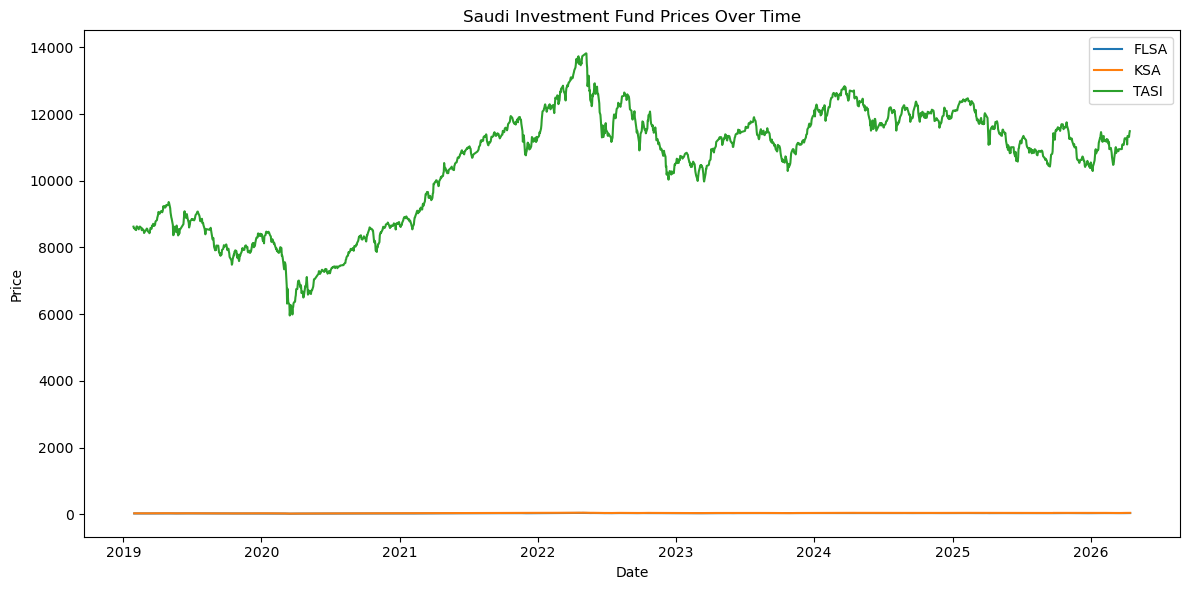

In [48]:
plt.figure(figsize=(12,6))
for ticker in df["Ticker"].unique():
    temp = df[df["Ticker"] == ticker]
    plt.plot(temp["Date"], temp["Close"], label=ticker)
plt.legend()
plt.title("Saudi Investment Fund Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

The line chart shows the historical closing prices of the three Saudi investment funds (KSA, FLSA, TASI) from 2019 to 2026. All three funds broadly follow the same Saudi market trend, which reflects their common underlying exposure to the Tadawul exchange.

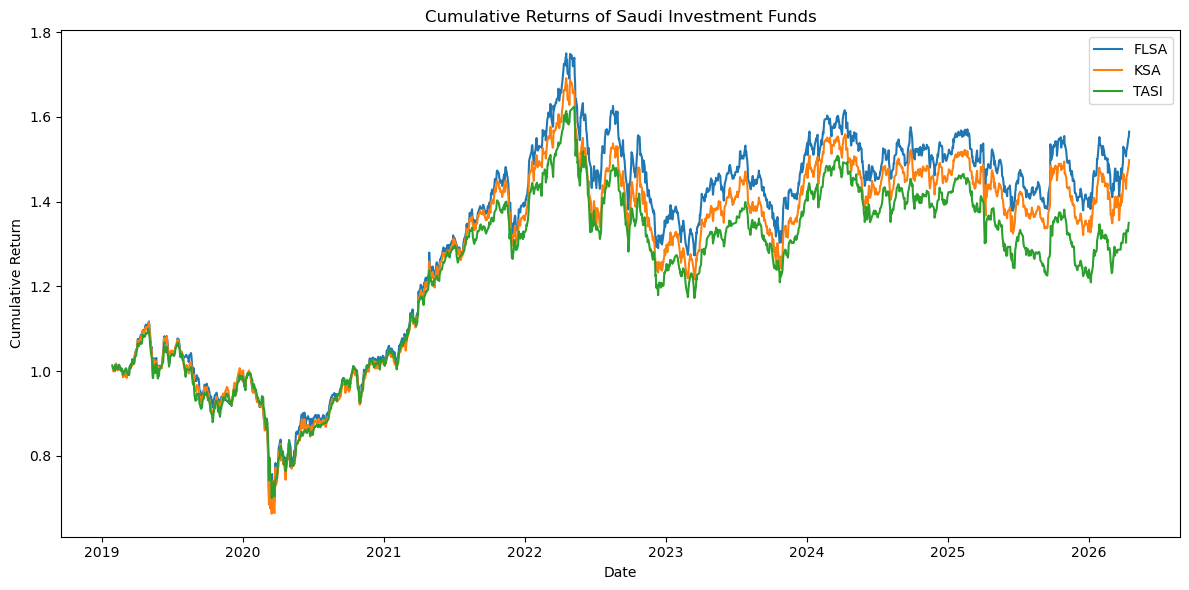

In [51]:
plt.figure(figsize=(12,6))
for ticker in df["Ticker"].unique():
    temp = df[df["Ticker"] == ticker].copy()
    temp["Cumulative_Return"] = (1 + temp["Daily_Return"]).cumprod()
    plt.plot(temp["Date"], temp["Cumulative_Return"], label=ticker)
plt.legend()
plt.title("Cumulative Returns of Saudi Investment Funds")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.tight_layout()
plt.show()

This plot shows how a 1-unit investment in each fund would have grown over time. Small differences between funds reflect tracking error and different index methodologies.

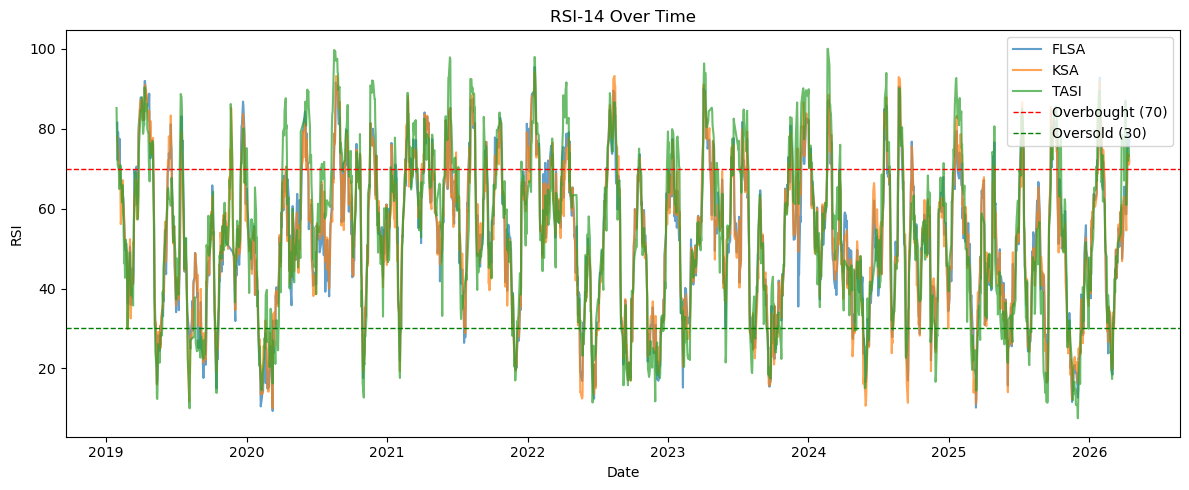

In [54]:
plt.figure(figsize=(12,5))
for ticker in df["Ticker"].unique():
    temp = df[df["Ticker"] == ticker]
    plt.plot(temp["Date"], temp["RSI_14"], label=ticker, alpha=0.7)
plt.axhline(70, color='red',   linestyle='--', linewidth=1, label='Overbought (70)')
plt.axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
plt.legend()
plt.title("RSI-14 Over Time")
plt.xlabel("Date")
plt.ylabel("RSI")
plt.tight_layout()
plt.show()

The RSI chart shows momentum signals over time. Values above 70 indicate overbought conditions (potential reversal downward), while values below 30 indicate oversold conditions (potential reversal upward). These signals are key features for the ML models.

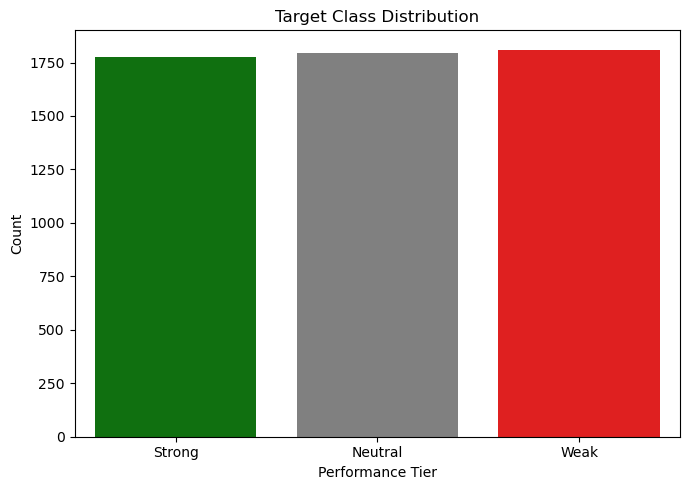

In [57]:
plt.figure(figsize=(7,5))
sns.countplot(x="Target", data=df, order=["Strong", "Neutral", "Weak"],
             hue="Target", palette={"Strong":"green","Neutral":"gray","Weak":"red"}, legend=False)
plt.title("Target Class Distribution")
plt.xlabel("Performance Tier")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

The target classes are balanced using quantile-based binning (each tier contains ~33% of the data). Balanced classes prevent model bias and lead to more reliable evaluation metrics.

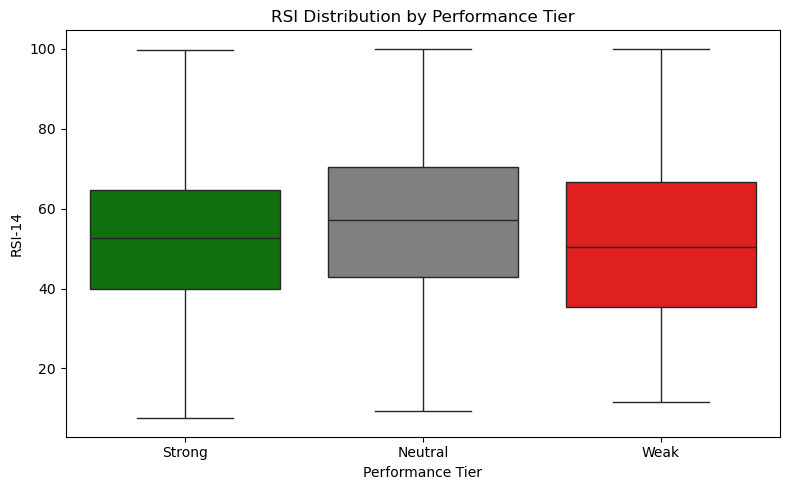

In [60]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Target", y="RSI_14", data=df,
            order=["Strong", "Neutral", "Weak"],
            hue="Target", palette={"Strong":"green","Neutral":"gray","Weak":"red"}, legend=False)
plt.title("RSI Distribution by Performance Tier")
plt.xlabel("Performance Tier")
plt.ylabel("RSI-14")
plt.tight_layout()
plt.show()

This chart confirms that RSI is a meaningful feature: Strong-performing periods tend to have lower RSI values (oversold → bounce), while Weak periods tend to have higher RSI (overbought → decline).

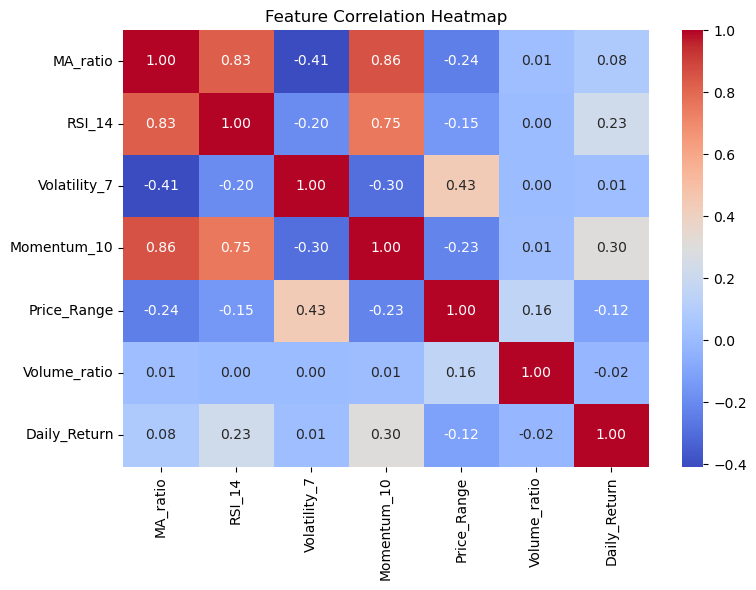

In [63]:
feature_cols = ["MA_ratio", "RSI_14", "Volatility_7", "Momentum_10",
                "Price_Range", "Volume_ratio", "Daily_Return"]
plt.figure(figsize=(8,6))
sns.heatmap(df[feature_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

The correlation heatmap shows the relationships between technical indicators. Low correlation between features indicates they capture different aspects of the market, which helps the models learn better.

In [66]:
df.columns

Index(['Date', 'Company_Name', 'Ticker', 'Sector', 'Industry', 'Open', 'High',
       'Low', 'Close', 'Adj_Close', 'Volume', 'Daily_Return', 'MA_5', 'MA_10',
       'MA_20', 'MA_ratio', 'Volatility_7', 'Momentum_10', 'Price_Range',
       'Volume_MA_5', 'Volume_ratio', 'RSI_14', 'Future_Return', 'Target'],
      dtype='object')

# بداية ال AI

In [69]:
df = df.sort_values(by="Date").copy()

In [71]:
features = [
    "Ticker",
    "MA_5", "MA_10", "MA_20", "MA_ratio",
    "RSI_14",
    "Volatility_7",
    "Momentum_10",
    "Price_Range",
    "Volume_ratio",
    "Open", "High", "Low", "Close", "Volume"
]

In [73]:
X = df[features]
y = df["Target"]

In [75]:
split_date = "2024-01-01"

le = LabelEncoder()
le.fit(df["Target"])

train = df[df["Date"] < split_date]
test  = df[df["Date"] >= split_date]

X_train = train[features]
X_test  = test[features]

y_train = le.transform(train["Target"])
y_test  = le.transform(test["Target"])

print('Train size:', X_train.shape)
print('Test size: ', X_test.shape)
print('Classes:   ', le.classes_)

Train size: (3673, 15)
Test size:  (1706, 15)
Classes:    ['Neutral' 'Strong' 'Weak']


In [77]:
cat_cols = ["Ticker"]
num_cols = ["MA_5", "MA_10", "MA_20", "MA_ratio", "RSI_14",
            "Volatility_7", "Momentum_10", "Price_Range",
            "Volume_ratio", "Open", "High", "Low", "Close", "Volume"]

In [79]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [81]:
models = {
    # استخدمنا solver مختلف (saga) وهو ممتاز للبيانات الكبيرة والمتنوعة
    "Logistic Regression": LogisticRegression(C=0.5, solver="saga", penalty="l2", max_iter=5000),

    # استخدمنا التحجيم (Pruning) عبر تحديد min_samples_leaf لمنع الشجرة من حفظ حالات شاذة
    "Decision Tree": DecisionTreeClassifier(max_depth=12, min_samples_leaf=10, criterion="entropy"),

    # تفعيل bootstrap وتحديد max_features لجعل الغابة أكثر عشوائية وقوة
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, max_features="sqrt", bootstrap=True),

    # استخدام subsampling (تدريب كل شجرة على جزء من البيانات فقط) لتقليل الانحياز
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=150, learning_rate=0.05, subsample=0.8, max_depth=4),

    # استخدام طبقتين متوسطتين مع زيادة الـ Alpha (Regularization) لتقليل التذبذب
    "MLP (Deep Learning)": MLPClassifier(hidden_layer_sizes=(100, 100), alpha=0.1, solver="adam", max_iter=1000)
}

In [83]:
results = []

for name, clf in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_test, y_pred, average="weighted", zero_division=0)

    results.append([name, acc, prec, rec, f1])

    print(f"\n{name}")
    print("-" * 50)
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_test, y_pred, target_names=le.classes_, zero_division=0))


Logistic Regression
--------------------------------------------------
Accuracy: 0.3751
              precision    recall  f1-score   support

     Neutral       0.40      0.30      0.34       618
      Strong       0.33      0.52      0.40       430
        Weak       0.40      0.36      0.38       658

    accuracy                           0.38      1706
   macro avg       0.38      0.39      0.37      1706
weighted avg       0.39      0.38      0.37      1706


Decision Tree
--------------------------------------------------
Accuracy: 0.3077
              precision    recall  f1-score   support

     Neutral       0.36      0.28      0.32       618
      Strong       0.23      0.31      0.26       430
        Weak       0.34      0.33      0.34       658

    accuracy                           0.31      1706
   macro avg       0.31      0.31      0.31      1706
weighted avg       0.32      0.31      0.31      1706


Random Forest
--------------------------------------------------


In [84]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])
results_df = results_df.sort_values(by="F1 Score", ascending=False).reset_index(drop=True)

print("\nFinal Comparison:")
print(results_df.to_string(index=False))


Final Comparison:
              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.375147   0.385051 0.375147  0.371645
      Random Forest  0.346424   0.354015 0.346424  0.345757
  Gradient Boosting  0.344080   0.351987 0.344080  0.343114
      Decision Tree  0.307737   0.320786 0.307737  0.310580
MLP (Deep Learning)  0.302462   0.320923 0.302462  0.299276


# المقارنات بين المودلز

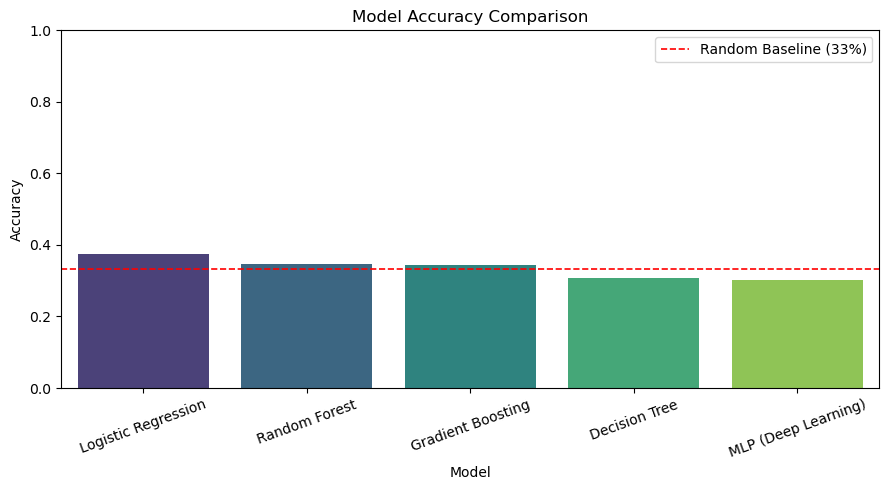

In [86]:
# ── Bar Chart: Accuracy Comparison ──────────────────────────────────────
plt.figure(figsize=(9,5))
sns.barplot(data=results_df, x="Model", y="Accuracy",
            hue="Model", palette="viridis", legend=False)
plt.axhline(0.333, color='red', linestyle='--', linewidth=1.2, label='Random Baseline (33%)')
plt.legend()
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

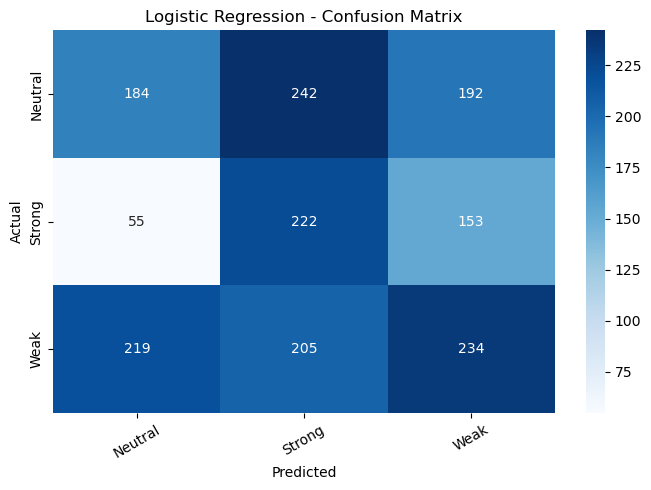

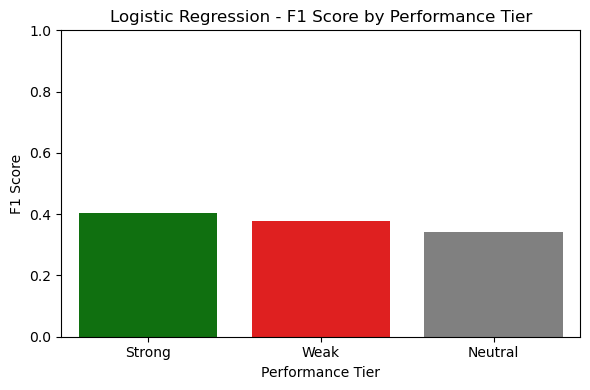

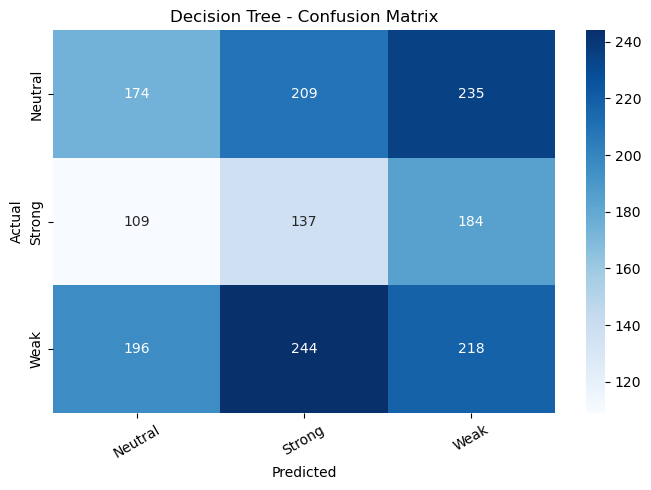

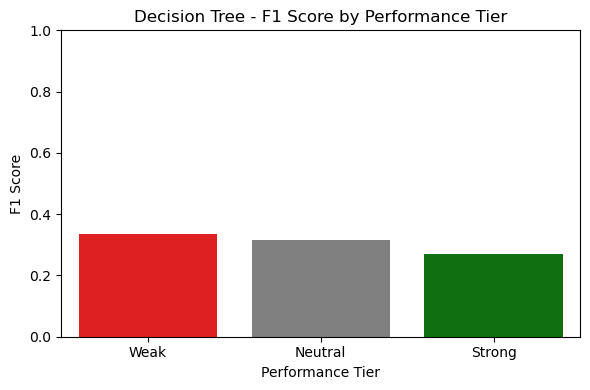

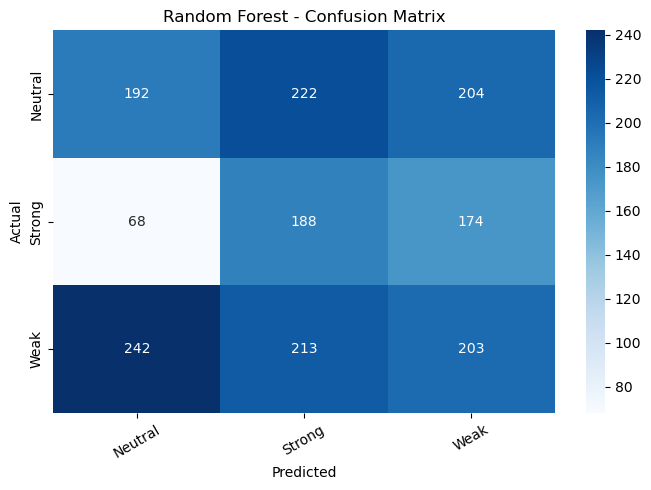

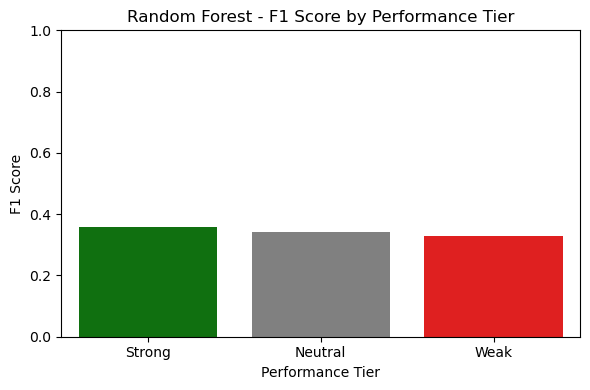

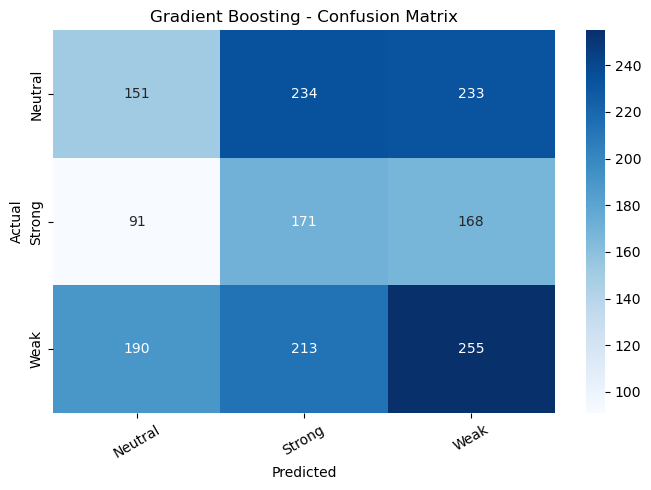

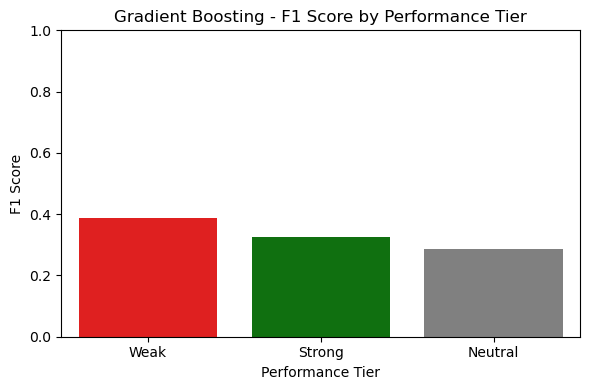

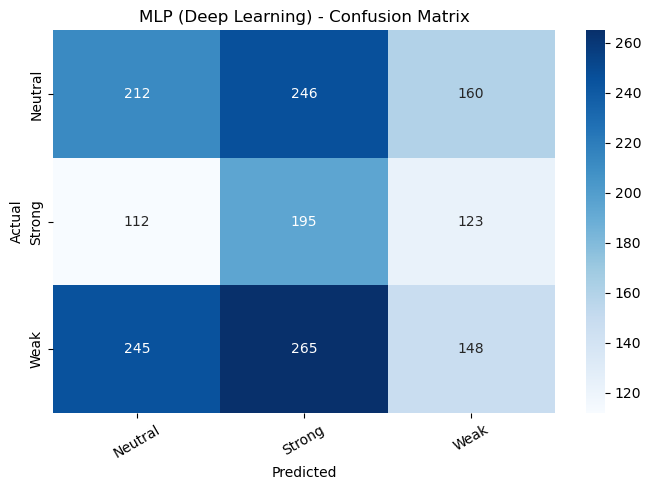

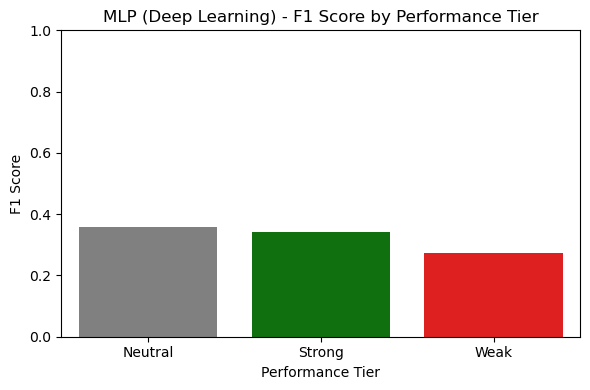

In [87]:
predictions = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clf)
    ])
    pipe.fit(X_train, y_train)
    predictions[name] = pipe.predict(X_test)

labels_idx = list(range(len(le.classes_)))

for name, y_pred in predictions.items():

    # ── 1) Confusion Matrix ───────────────────────────────────────────────
    cm = confusion_matrix(y_test, y_pred, labels=labels_idx)

    plt.figure(figsize=(7,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le.classes_,
                yticklabels=le.classes_)
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    # ── 2) F1 Score per Tier ─────────────────────────────────────────────
    report = classification_report(
        y_test, y_pred,
        labels=labels_idx,
        target_names=le.classes_,
        output_dict=True,
        zero_division=0
    )

    f1_scores = {cls: report[cls]['f1-score'] for cls in le.classes_}

    f1_df = pd.DataFrame({
        "Tier": list(f1_scores.keys()),
        "F1 Score": list(f1_scores.values())
    }).sort_values(by='F1 Score', ascending=False)

    plt.figure(figsize=(6,4))
    sns.barplot(data=f1_df, x="Tier", y="F1 Score",
                hue="Tier", palette={"Strong":"green","Neutral":"gray","Weak":"red"}, legend=False)
    plt.title(f"{name} - F1 Score by Performance Tier")
    plt.xlabel("Performance Tier")
    plt.ylabel("F1 Score")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()